[Mohit Saharan](https://linkedin.com/in/msaharan), 20260501, P15

Apache 2.0 License (view [license](https://github.com/msaharan/dsaiengineering/blob/c199840f1fac7083cc4f2b2c7ed1b812d7913fe2/LICENSE))

# TabPFN and TabICL for fraud detection - v1

This notebook compares TabICLv2, TabPFN, and classical supervised ML baselines on a practical fraud-detection workflow. Work in progress.

## How to run this notebook on Kaggle

1. Import this notebook into Kaggle.
2. Enable GPU acceleration.
3. Turn on Internet access because the notebook downloads packages and the public fraud CSV.
4. Add a Kaggle secret named `TABPFN_TOKEN` if you want to run local TabPFN weights in a headless Kaggle session. You need to accept the Prior Labs license first.
5. Optionally add `HF_TOKEN` for Hugging Face downloads. TabICL is usually downloadable without it, but using a token can avoid rate-limit issues.

If TabPFN or TabICL fail to import or download, the notebook records the error and continues with the remaining models.


In [1]:
%%time
# Kaggle / Colab setup.
# Run this cell once. If imports still fail, restart the notebook session and continue below.

import shutil
import subprocess
import sys


def install_packages(*packages):
    if shutil.which("uv"):
        command = ["uv", "pip", "install", *packages]
    else:
        command = [sys.executable, "-m", "pip", "install", *packages]

    print("Installing:", " ".join(packages))
    subprocess.check_call(command)


install_packages("xgboost", "rich", "openml")
install_packages("tabpfn")
install_packages("tabicl")


Installing: xgboost rich openml
Installing: tabpfn


Using Python 3.12.12 environment at: /usr
Audited 3 packages in 124ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 135ms


Installing: tabicl
CPU times: user 5 ms, sys: 1.04 ms, total: 6.04 ms
Wall time: 423 ms


Using Python 3.12.12 environment at: /usr
Audited 1 package in 130ms


## 0. Imports, Secrets, and Configuration

In [2]:
import os
import time
import warnings
from traceback import format_exception_only

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import display
from rich.console import Console

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
console = Console()

SEED = 42
N_TFM_ESTIMATORS = 8
CLASSICAL_TUNING_ITERATIONS = 16
CLASSICAL_TUNING_JOBS = 1
TUNE_CLASSICAL_MODELS = True
TRAIN_END_FRACTION_BY_TIME = 0.60
VALIDATION_END_FRACTION_BY_TIME = 0.70
CALIBRATION_END_FRACTION_BY_TIME = 0.80
MAX_TRAIN_NORMAL = 4000
MAX_CONTEXT_NORMAL = 4000
MAX_TEST_NORMAL = 20000
USE_TIME_AS_FEATURE = True
EVALUATE_TFM_ON_FULL_HOLDOUT = True

np.random.seed(SEED)

try:
    CUDA_AVAILABLE = torch.cuda.is_available()
    CUDA_DEVICE_COUNT = torch.cuda.device_count() if CUDA_AVAILABLE else 0
except Exception:
    CUDA_AVAILABLE = False
    CUDA_DEVICE_COUNT = 0

if CUDA_AVAILABLE:
    TABICL_DEVICE = "cuda:0"
    TABPFN_DEVICE = [f"cuda:{i}" for i in range(CUDA_DEVICE_COUNT)]
else:
    TABICL_DEVICE = "cpu"
    TABPFN_DEVICE = "cpu"

print(f"CUDA available: {CUDA_AVAILABLE}")
print(f"CUDA device count: {CUDA_DEVICE_COUNT}")
print(f"TabICL device: {TABICL_DEVICE}")
print(f"TabPFN device: {TABPFN_DEVICE}")
print(f"TFM ensemble members: {N_TFM_ESTIMATORS}")
print(f"Tune classical models: {TUNE_CLASSICAL_MODELS}")
print(f"Classical tuning iterations per model: {CLASSICAL_TUNING_ITERATIONS}")
print(f"Train/validation/calibration/test time fractions: 0-{TRAIN_END_FRACTION_BY_TIME:.0%}, {TRAIN_END_FRACTION_BY_TIME:.0%}-{VALIDATION_END_FRACTION_BY_TIME:.0%}, {VALIDATION_END_FRACTION_BY_TIME:.0%}-{CALIBRATION_END_FRACTION_BY_TIME:.0%}, {CALIBRATION_END_FRACTION_BY_TIME:.0%}-100%")
print(f"Use Time as model feature: {USE_TIME_AS_FEATURE}")
print(f"Evaluate TFMs on full holdout: {EVALUATE_TFM_ON_FULL_HOLDOUT}")


CUDA available: True
CUDA device count: 2
TabICL device: cuda:0
TabPFN device: ['cuda:0', 'cuda:1']
TFM ensemble members: 8
Tune classical models: True
Classical tuning iterations per model: 16
Train/validation/calibration/test time fractions: 0-60%, 60%-70%, 70%-80%, 80%-100%
Use Time as model feature: True
Evaluate TFMs on full holdout: True


In [3]:
def load_secret(name):
    value = os.environ.get(name)
    if value:
        return value

    try:
        from kaggle_secrets import UserSecretsClient

        value = UserSecretsClient().get_secret(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass

    try:
        from google.colab import userdata

        value = userdata.get(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass

    return None


hf_token = load_secret("HF_TOKEN")
tabpfn_token = load_secret("TABPFN_TOKEN")

if hf_token:
    print("HF_TOKEN found.")
else:
    print("HF_TOKEN not found. Hugging Face downloads will use anonymous requests.")

if tabpfn_token:
    print("TABPFN_TOKEN found.")
else:
    os.environ["TABPFN_NO_BROWSER"] = "1"
    print("TABPFN_TOKEN not found. TabPFN will be skipped or fail quickly instead of waiting for browser auth.")

_ = os.environ.setdefault("TABPFN_DISABLE_TELEMETRY", "1")

HF_TOKEN found.
TABPFN_TOKEN found.


## 1. Load the Credit-Card Fraud Dataset

This notebook uses the public credit-card fraud CSV originally released with anonymized transaction features, `Time`, `Amount`, and a binary fraud label. The primary loader uses a public CSV URL that preserves the `Time` column. OpenML is kept only as a fallback, and the notebook stops if the loaded data does not contain `Time`, because the workflow depends on a real temporal holdout.


In [4]:
CREDIT_CARD_FRAUD_CSV_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"


def load_creditcard_fraud_data():
    try:
        df = pd.read_csv(CREDIT_CARD_FRAUD_CSV_URL)
        return df, "Class", CREDIT_CARD_FRAUD_CSV_URL
    except Exception as csv_exc:
        print(f"Primary CSV load failed: {type(csv_exc).__name__}: {csv_exc}")
        print("Falling back to OpenML data_id=1597.")

    raw = fetch_openml(data_id=1597, as_frame=True, parser="auto")
    df = raw.frame.copy()
    target_column = "Class" if "Class" in df.columns else raw.target_names[0]
    return df, target_column, "OpenML data_id=1597 fallback"


df, target_column, data_source = load_creditcard_fraud_data()

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(subset=[target_column]).copy()
df[target_column] = df[target_column].astype(int)

if "Time" not in df.columns:
    raise ValueError(
        "The loaded dataset does not include a `Time` column, so this notebook cannot "
        "run the temporal holdout as written. Use the CSV source that preserves `Time`, "
        "or revise the workflow to describe an ordered holdout instead."
    )

df = df.sort_values("Time").reset_index(drop=True)

print(f"Dataset source: {data_source}")
print(f"Dataset shape: {df.shape}")
print(f"Target column: {target_column}")
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f}")
display(df.head())
display(df[target_column].value_counts().rename("count").to_frame())
print(f"Fraud rate: {df[target_column].mean():.4%}")


Dataset source: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Dataset shape: (284807, 31)
Target column: Class
Time range: 0 to 172792


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
3,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0


,count
Class,
0,284315
1,492


Fraud rate: 0.1727%


## 2. Lightweight Data Checks

Before modeling, inspect the target imbalance, missing values, feature types, and feature cardinality. In a real workflow, this is where I would also look for leakage-prone fields.

In [5]:
X_full = df.drop(columns=[target_column])
y_full = df[target_column].astype(int)

checks = pd.DataFrame(
    {
        "dtype": X_full.dtypes.astype(str),
        "missing_rate": X_full.isna().mean(),
        "n_unique": X_full.nunique(dropna=False),
    }
).sort_values(["missing_rate", "n_unique"], ascending=False)

summary = pd.DataFrame(
    {
        "value": [
            len(df),
            X_full.shape[1],
            int(y_full.sum()),
            y_full.mean(),
        ]
    },
    index=["rows", "features", "fraud_rows", "fraud_rate"],
)

display(summary)
display(checks.head(20))

,value
rows,284807.000000
features,30.000000
fraud_rows,492.000000
fraud_rate,0.001727


,dtype,missing_rate,n_unique
V1,float64,0.0,275663
V2,float64,0.0,275663
V3,float64,0.0,275663
V4,float64,0.0,275663
V5,float64,0.0,275663
V6,float64,0.0,275663
V7,float64,0.0,275663
V8,float64,0.0,275663
V9,float64,0.0,275663
V10,float64,0.0,275663


## 3. Time-Aware Split Design

Fraud systems usually care about future transactions. This notebook therefore uses four time windows rather than random cross-validation:

- earliest 60% of transactions: classical training sample;
- next 10% of transactions: full-prevalence validation window for classical model selection;
- next 10% of transactions: full-prevalence calibration window for post-hoc probability calibration;
- final 20% of transactions: future holdout.

The `Time` column is used to order transactions and create the split. In the default notebook, `Time` is excluded from the model features. This sensitivity run sets `USE_TIME_AS_FEATURE = True`, so `Time` is included as a model feature to test how much position-in-dataset information changes the results.

To keep the notebook Kaggle-friendly, classical hyperparameter tuning uses a sampled training fold and a full-prevalence validation fold. After model selection, classical models are refit on full historical windows before the final holdout. TFM context remains sampled for runtime, but TFM inference is run on both the sampled and full final holdouts. Validation, calibration, and the full final holdout keep the natural fraud base rate.

The sampled TFM context intentionally over-represents fraud compared with deployment prevalence because all fraud rows are kept while normal rows are capped. That is useful under notebook row limits, but it can affect the raw probability scale of TabICL and TabPFN. For that reason, I interpret TFM scores primarily as ranking scores unless calibration is validated separately.

One important limitation is that rare-event time windows can contain very few positive examples. In the current run, the validation window has 24 fraud rows and the calibration window has 33 fraud rows. That is enough for a practical public notebook, but it makes model selection and calibration noisy. I therefore treat calibration as a diagnostic workflow step rather than proof of production-ready probability estimates.


In [6]:
train_end_idx = int(len(df) * TRAIN_END_FRACTION_BY_TIME)
validation_end_idx = int(len(df) * VALIDATION_END_FRACTION_BY_TIME)
calibration_end_idx = int(len(df) * CALIBRATION_END_FRACTION_BY_TIME)

train_period = df.iloc[:train_end_idx].copy()
validation_period = df.iloc[train_end_idx:validation_end_idx].copy()
calibration_period = df.iloc[validation_end_idx:calibration_end_idx].copy()
test_period = df.iloc[calibration_end_idx:].copy()


def sample_binary_window(frame, max_normal_rows, random_state=SEED):
    fraud_rows = frame[frame[target_column] == 1]
    normal_rows = frame[frame[target_column] == 0]

    if max_normal_rows is None or len(normal_rows) <= max_normal_rows:
        sampled_normal = normal_rows
    else:
        sampled_normal = normal_rows.sample(n=max_normal_rows, random_state=random_state)

    return (
        pd.concat([fraud_rows, sampled_normal], axis=0)
        .sort_values("Time")
        .reset_index(drop=True)
    )


train_df = sample_binary_window(train_period, MAX_TRAIN_NORMAL)
validation_df = validation_period.reset_index(drop=True)
calibration_df = calibration_period.reset_index(drop=True)
context_source_df = pd.concat([train_period, validation_period, calibration_period], axis=0).reset_index(drop=True)
context_df = sample_binary_window(context_source_df, MAX_CONTEXT_NORMAL)
test_sample_df = sample_binary_window(test_period, MAX_TEST_NORMAL)
test_full_df = test_period.reset_index(drop=True)

feature_columns = [column for column in df.columns if column != target_column]
if not USE_TIME_AS_FEATURE and "Time" in feature_columns:
    feature_columns.remove("Time")

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].astype(int).copy()
X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].astype(int).copy()
X_calibration = calibration_df[feature_columns].copy()
y_calibration = calibration_df[target_column].astype(int).copy()
X_context = context_df[feature_columns].copy()
y_context = context_df[target_column].astype(int).copy()
X_test_sample = test_sample_df[feature_columns].copy()
y_test_sample = test_sample_df[target_column].astype(int).copy()
X_test_full = test_full_df[feature_columns].copy()
y_test_full = test_full_df[target_column].astype(int).copy()

X_classical_tune = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
y_classical_tune = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)
validation_fold_indices = np.concatenate([
    np.full(len(X_train), -1, dtype=int),
    np.zeros(len(X_validation), dtype=int),
])

classical_base_train_df = pd.concat([train_period, validation_period], axis=0).reset_index(drop=True)
classical_final_train_df = pd.concat([train_period, validation_period, calibration_period], axis=0).reset_index(drop=True)
X_classical_base_train = classical_base_train_df[feature_columns].copy()
y_classical_base_train = classical_base_train_df[target_column].astype(int).copy()
X_classical_final_train = classical_final_train_df[feature_columns].copy()
y_classical_final_train = classical_final_train_df[target_column].astype(int).copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "train_window_sampled",
            "rows": len(train_df),
            "fraud_rows": int(y_train.sum()),
            "fraud_rate": y_train.mean(),
            "time_min": train_df["Time"].min(),
            "time_max": train_df["Time"].max(),
        },
        {
            "split": "validation_window_full",
            "rows": len(validation_df),
            "fraud_rows": int(y_validation.sum()),
            "fraud_rate": y_validation.mean(),
            "time_min": validation_df["Time"].min(),
            "time_max": validation_df["Time"].max(),
        },
        {
            "split": "calibration_window_full",
            "rows": len(calibration_df),
            "fraud_rows": int(y_calibration.sum()),
            "fraud_rate": y_calibration.mean(),
            "time_min": calibration_df["Time"].min(),
            "time_max": calibration_df["Time"].max(),
        },
        {
            "split": "tfm_context_sampled",
            "rows": len(context_df),
            "fraud_rows": int(y_context.sum()),
            "fraud_rate": y_context.mean(),
            "time_min": context_df["Time"].min(),
            "time_max": context_df["Time"].max(),
        },
        {
            "split": "test_holdout_sampled",
            "rows": len(test_sample_df),
            "fraud_rows": int(y_test_sample.sum()),
            "fraud_rate": y_test_sample.mean(),
            "time_min": test_sample_df["Time"].min(),
            "time_max": test_sample_df["Time"].max(),
        },
        {
            "split": "test_holdout_full",
            "rows": len(test_full_df),
            "fraud_rows": int(y_test_full.sum()),
            "fraud_rate": y_test_full.mean(),
            "time_min": test_full_df["Time"].min(),
            "time_max": test_full_df["Time"].max(),
        },
    ]
)

display(split_summary)
print(f"Using Time as feature: {USE_TIME_AS_FEATURE}")
print(f"Feature count: {len(feature_columns)}")
print(f"Classical tuning rows: {len(X_classical_tune):,}")
print(f"Classical base-fit rows for calibration: {len(X_classical_base_train):,}")
print(f"Classical final-training rows: {len(X_classical_final_train):,}")
print(f"Classical calibration rows: {len(X_calibration):,}")
print(f"TFM context rows: {len(X_context):,}")


,split,rows,fraud_rows,fraud_rate,time_min,time_max
0,train_window_sampled,4360,360,0.082569,18.0,120395.0
1,validation_window_full,28480,24,0.000843,120396.0,132928.0
2,calibration_window_full,28481,33,0.001159,132929.0,145247.0
3,tfm_context_sampled,4417,417,0.094408,26.0,145232.0
4,test_holdout_sampled,20075,75,0.003736,145248.0,172786.0
5,test_holdout_full,56962,75,0.001317,145248.0,172792.0


Using Time as feature: True
Feature count: 30
Classical tuning rows: 32,840
Classical base-fit rows for calibration: 199,364
Classical final-training rows: 227,845
Classical calibration rows: 28,481
TFM context rows: 4,417


## 4. Model Registry and Time-Aware Classical Tuning

The classical baselines use the validation time window for hyperparameter selection with Average Precision as the scoring metric. Tuning uses a sampled training fold for runtime, then the selected classical models are refit on full pre-holdout historical windows. Calibrated classical variants fit the selected base model on the full train+validation history and reserve the later calibration window for sigmoid calibration.

This means calibrated and uncalibrated classical rows are not a pure one-variable comparison. The uncalibrated model gets the calibration window as additional final-refit data; the calibrated model uses that same window to learn the probability mapping. That is a realistic production pattern, but any AP difference should be read as a workflow difference, not simply as calibration helping or hurting ranking quality.

The model set is intentionally compact: Logistic Regression as a simple, common fraud/credit-risk baseline, and XGBoost as a strong boosted-tree baseline. Random Forest and CatBoost are omitted here so the compute budget goes into validation design and operational diagnostics rather than a larger model list. TabICL and TabPFN are included as direct foundation-model comparators; their own tuning options are not explored here.


In [7]:
def short_error(exc):
    return "".join(format_exception_only(type(exc), exc)).strip().replace("\n", " ")[:400]


def try_import_tabicl():
    try:
        from tabicl import TabICLClassifier

        return TabICLClassifier, None
    except Exception as exc:
        return None, short_error(exc)


def try_import_tabpfn():
    try:
        from tabpfn import TabPFNClassifier

        return TabPFNClassifier, None
    except Exception as exc:
        return None, short_error(exc)


TabICLClassifier, tabicl_import_error = try_import_tabicl()
TabPFNClassifier, tabpfn_import_error = try_import_tabpfn()

if tabicl_import_error:
    print(f"TabICL import failed: {tabicl_import_error}")
else:
    print("TabICL import succeeded.")

if tabpfn_import_error:
    print(f"TabPFN import failed: {tabpfn_import_error}")
else:
    print("TabPFN import succeeded.")


def make_preprocessor():
    return make_column_transformer(
        (
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            make_column_selector(dtype_include=["object", "category"]),
        ),
        remainder="passthrough",
    )


def tabicl_batch_size():
    return 1 if TABICL_DEVICE == "cpu" else 4


def make_classical_search(name, estimator, param_distributions):
    if not TUNE_CLASSICAL_MODELS or not param_distributions:
        return estimator

    cv_split = [(np.where(validation_fold_indices == -1)[0], np.where(validation_fold_indices == 0)[0])]
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=CLASSICAL_TUNING_ITERATIONS,
        scoring="average_precision",
        cv=cv_split,
        refit=False,
        random_state=SEED,
        n_jobs=CLASSICAL_TUNING_JOBS,
        error_score=np.nan,
        verbose=1,
    )


def classification_model_list(y_train_for_weights):
    positive_count = max(int(np.sum(y_train_for_weights == 1)), 1)
    negative_count = max(int(np.sum(y_train_for_weights == 0)), 1)
    scale_pos_weight = negative_count / positive_count
    sqrt_scale_pos_weight = np.sqrt(scale_pos_weight)

    logistic_regression = make_pipeline(
        make_preprocessor(),
        StandardScaler(),
        LogisticRegression(max_iter=3000, solver="liblinear", random_state=SEED),
    )
    xgboost = make_pipeline(
        make_preprocessor(),
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
        ),
    )

    models = [
        {
            "name": "Dummy",
            "model": DummyClassifier(strategy="prior"),
            "fit_X": X_classical_final_train,
            "fit_y": y_classical_final_train,
            "evaluate_full_holdout": True,
            "model_family": "baseline",
        },
        {
            "name": "LogisticRegression",
            "model": make_classical_search(
                "LogisticRegression",
                logistic_regression,
                {
                    "logisticregression__C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
                    "logisticregression__penalty": ["l1", "l2"],
                    "logisticregression__class_weight": [None, "balanced"],
                },
            ),
            "fit_X": X_classical_tune,
            "fit_y": y_classical_tune,
            "final_refit_X": X_classical_final_train,
            "final_refit_y": y_classical_final_train,
            "calibration_base_fit_X": X_classical_base_train,
            "calibration_base_fit_y": y_classical_base_train,
            "calibration_X": X_calibration,
            "calibration_y": y_calibration,
            "evaluate_full_holdout": True,
            "model_family": "classical",
            "calibrate_on_validation": True,
        },
        {
            "name": "XGBoost",
            "model": make_classical_search(
                "XGBoost",
                xgboost,
                {
                    "xgbclassifier__n_estimators": [200, 400, 700],
                    "xgbclassifier__max_depth": [2, 3, 4, 6],
                    "xgbclassifier__learning_rate": [0.01, 0.03, 0.1],
                    "xgbclassifier__subsample": [0.8, 1.0],
                    "xgbclassifier__colsample_bytree": [0.8, 1.0],
                    "xgbclassifier__scale_pos_weight": [1.0, sqrt_scale_pos_weight, scale_pos_weight],
                    "xgbclassifier__reg_lambda": [1.0, 3.0, 10.0],
                },
            ),
            "fit_X": X_classical_tune,
            "fit_y": y_classical_tune,
            "final_refit_X": X_classical_final_train,
            "final_refit_y": y_classical_final_train,
            "calibration_base_fit_X": X_classical_base_train,
            "calibration_base_fit_y": y_classical_base_train,
            "calibration_X": X_calibration,
            "calibration_y": y_calibration,
            "evaluate_full_holdout": True,
            "model_family": "classical",
            "calibrate_on_validation": True,
        },
    ]

    if TabICLClassifier is not None:
        models.append(
            {
                "name": "TabICLv2",
                "model": TabICLClassifier(
                    n_estimators=N_TFM_ESTIMATORS,
                    device=TABICL_DEVICE,
                    batch_size=tabicl_batch_size(),
                    random_state=SEED,
                ),
                "fit_X": X_context,
                "fit_y": y_context,
                "evaluate_full_holdout": EVALUATE_TFM_ON_FULL_HOLDOUT,
                "model_family": "tfm",
            }
        )

    if TabPFNClassifier is not None:
        models.append(
            {
                "name": "TabPFN",
                "model": TabPFNClassifier(
                    n_estimators=N_TFM_ESTIMATORS,
                    device=TABPFN_DEVICE,
                    random_state=SEED,
                ),
                "fit_X": X_context,
                "fit_y": y_context,
                "evaluate_full_holdout": EVALUATE_TFM_ON_FULL_HOLDOUT,
                "model_family": "tfm",
            }
        )

    return models


TabICL import succeeded.
TabPFN import succeeded.


## 5. Evaluation Helpers

Average Precision remains the primary model-quality metric, but the notebook also tracks the evaluation holdout, fraud base rate, Brier score, fit time, calibration time, and prediction time separately. This matters because a sampled TFM holdout answers a different operational question than a full final holdout.


In [8]:
def row_slice(X, start, stop):
    if hasattr(X, "iloc"):
        return X.iloc[start:stop]
    return X[start:stop]


def positive_class_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if proba.ndim != 2 or proba.shape[1] < 2:
        raise ValueError("Expected a two-column probability array for binary classification.")

    classes = getattr(estimator, "classes_", None)
    if classes is not None and 1 in list(classes):
        positive_index = list(classes).index(1)
    else:
        positive_index = 1

    return proba[:, positive_index]


def predict_proba_in_chunks(estimator, X, chunk_size=4096):
    chunks = []
    for start in range(0, len(X), chunk_size):
        stop = min(start + chunk_size, len(X))
        chunks.append(positive_class_proba(estimator, row_slice(X, start, stop)))
    return np.concatenate(chunks)


def top_rate_precision_recall(y_true, y_proba, rate):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    k = max(1, int(np.ceil(rate * len(y_true))))
    selected = order[:k]
    positives_found = int(y_true[selected].sum())
    total_positives = max(int(y_true.sum()), 1)
    return positives_found / k, positives_found / total_positives, k


def metric_row(
    model_name,
    model_family,
    holdout_name,
    y_true,
    y_proba,
    fit_seconds,
    predict_seconds,
    cv_average_precision,
    best_params,
    calibration_seconds=0.0,
    timing_notes="",
):
    y_proba = np.clip(y_proba, 1e-7, 1 - 1e-7)
    top_005_precision, top_005_recall, top_005_alerts = top_rate_precision_recall(y_true, y_proba, 0.005)
    top_010_precision, top_010_recall, top_010_alerts = top_rate_precision_recall(y_true, y_proba, 0.01)

    return {
        "Model": model_name,
        "Family": model_family,
        "Holdout": holdout_name,
        "Rows": len(y_true),
        "Fraud Rate": float(np.mean(y_true)),
        "Average Precision": average_precision_score(y_true, y_proba),
        "Top 0.5% Alerts": top_005_alerts,
        "Top 0.5% Precision": top_005_precision,
        "Top 0.5% Recall": top_005_recall,
        "Top 1% Alerts": top_010_alerts,
        "Top 1% Precision": top_010_precision,
        "Top 1% Recall": top_010_recall,
        "CV/Validation Average Precision": cv_average_precision,
        "ROC AUC": roc_auc_score(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba, labels=[0, 1]),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Balanced Accuracy @ 0.5": balanced_accuracy_score(y_true, y_proba >= 0.5),
        "Fit Seconds": fit_seconds,
        "Calibration Seconds": calibration_seconds,
        "Predict Seconds": predict_seconds,
        "Total Seconds": fit_seconds + calibration_seconds + predict_seconds,
        "Timing Notes": timing_notes,
        "Best Params": best_params,
        "Error": "",
    }


def best_estimator_from_search(search_model):
    if hasattr(search_model, "best_params_"):
        estimator = clone(search_model.estimator)
        estimator.set_params(**search_model.best_params_)
        return estimator
    return clone(search_model)


def make_prefit_calibrator(prefit_estimator, X_calibration, y_calibration, method="sigmoid"):
    try:
        from sklearn.frozen import FrozenEstimator

        calibrator = CalibratedClassifierCV(FrozenEstimator(prefit_estimator), method=method)
        return calibrator.fit(X_calibration, y_calibration)
    except Exception:
        calibrator = CalibratedClassifierCV(prefit_estimator, method=method, cv="prefit")
        return calibrator.fit(X_calibration, y_calibration)


def make_validation_calibrated_variant(search_model, spec):
    if spec.get("calibration_X") is None:
        return None, np.nan

    calibration_start = time.perf_counter()
    base_estimator = best_estimator_from_search(search_model)
    base_estimator.fit(spec["calibration_base_fit_X"], spec["calibration_base_fit_y"])
    calibrated_model = make_prefit_calibrator(base_estimator, spec["calibration_X"], spec["calibration_y"], method="sigmoid")
    calibration_seconds = time.perf_counter() - calibration_start
    return calibrated_model, calibration_seconds


def append_prediction_rows(
    rows,
    predictions,
    model_name,
    model_family,
    model,
    holdouts,
    evaluate_full_holdout,
    fit_seconds,
    cv_average_precision,
    best_params,
    calibration_seconds=0.0,
    timing_notes="",
):
    for holdout_name, X_eval, y_eval in holdouts:
        if holdout_name == "full" and not evaluate_full_holdout:
            continue

        predict_start = time.perf_counter()
        y_proba = predict_proba_in_chunks(model, X_eval)
        predict_seconds = time.perf_counter() - predict_start
        y_proba = np.clip(y_proba, 1e-7, 1 - 1e-7)
        predictions[(model_name, holdout_name)] = y_proba
        rows.append(
            metric_row(
                model_name,
                model_family,
                holdout_name,
                y_eval,
                y_proba,
                fit_seconds,
                predict_seconds,
                cv_average_precision,
                best_params,
                calibration_seconds=calibration_seconds,
                timing_notes=timing_notes,
            )
        )


def evaluate_models(model_specs, holdouts):
    rows = []
    predictions = {}

    for spec in model_specs:
        name = spec["name"]
        model = spec["model"]
        model_family = spec["model_family"]
        console.rule(name)

        try:
            fit_start = time.perf_counter()
            model.fit(spec["fit_X"], spec["fit_y"])
            search_or_fit_seconds = time.perf_counter() - fit_start

            cv_average_precision = getattr(model, "best_score_", np.nan)
            best_params = getattr(model, "best_params_", "")
            if hasattr(model, "best_score_"):
                print(f"Best validation Average Precision: {model.best_score_:.4f}")
                print(f"Best params: {model.best_params_}")

            prediction_model = model
            final_refit_seconds = 0.0
            if "final_refit_X" in spec:
                final_refit_start = time.perf_counter()
                prediction_model = best_estimator_from_search(model)
                prediction_model.fit(spec["final_refit_X"], spec["final_refit_y"])
                final_refit_seconds = time.perf_counter() - final_refit_start
                print(f"Final refit on train+validation+calibration data: {final_refit_seconds:.1f} seconds")

            fit_seconds = search_or_fit_seconds + final_refit_seconds

            if model_family == "classical":
                timing_notes = "validation-window tuning + final pre-holdout refit"
            elif model_family == "baseline":
                timing_notes = "simple baseline fit on pre-holdout data"
            else:
                timing_notes = "fit may include first-run checkpoint download/model loading"

            append_prediction_rows(
                rows,
                predictions,
                name,
                model_family,
                prediction_model,
                holdouts,
                spec["evaluate_full_holdout"],
                fit_seconds,
                cv_average_precision,
                best_params,
                timing_notes=timing_notes,
            )

            if spec.get("calibrate_on_validation", False):
                calibrated_model, calibration_seconds = make_validation_calibrated_variant(model, spec)
                if calibrated_model is not None:
                    calibrated_name = f"{name}Calibrated"
                    append_prediction_rows(
                        rows,
                        predictions,
                        calibrated_name,
                        f"{model_family}_calibrated",
                        calibrated_model,
                        holdouts,
                        spec["evaluate_full_holdout"],
                        search_or_fit_seconds,
                        cv_average_precision,
                        best_params,
                        calibration_seconds=calibration_seconds,
                        timing_notes="validation tuning + train/validation base fit + separate calibration-window sigmoid calibration",
                    )
                    print(f"Added calibrated variant: {calibrated_name} ({calibration_seconds:.1f} calibration seconds)")

            print(f"Finished {name}: fit/search/refit {fit_seconds:.1f} seconds")
        except Exception as exc:
            error = short_error(exc)
            rows.append(
                {
                    "Model": name,
                    "Family": model_family,
                    "Holdout": "fit_or_predict_failed",
                    "Rows": np.nan,
                    "Fraud Rate": np.nan,
                    "Average Precision": np.nan,
                    "Top 0.5% Alerts": np.nan,
                    "Top 0.5% Precision": np.nan,
                    "Top 0.5% Recall": np.nan,
                    "Top 1% Alerts": np.nan,
                    "Top 1% Precision": np.nan,
                    "Top 1% Recall": np.nan,
                    "CV/Validation Average Precision": np.nan,
                    "ROC AUC": np.nan,
                    "Log Loss": np.nan,
                    "Brier Score": np.nan,
                    "Balanced Accuracy @ 0.5": np.nan,
                    "Fit Seconds": np.nan,
                    "Calibration Seconds": np.nan,
                    "Predict Seconds": np.nan,
                    "Total Seconds": np.nan,
                    "Timing Notes": "",
                    "Best Params": "",
                    "Error": error,
                }
            )
            print(f"{name} failed: {error}")

    summary = pd.DataFrame(rows)
    return summary.sort_values(["Holdout", "Average Precision"], ascending=[True, False], na_position="last"), predictions


def plot_precision_recall_curves(predictions, y_by_holdout, holdout_name, title, output_path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    plotted = False

    for (model_name, prediction_holdout), y_proba in predictions.items():
        if prediction_holdout != holdout_name:
            continue
        y_true = y_by_holdout[holdout_name]
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        ax.plot(recall, precision, label=f"{model_name} AP={ap:.3f}")
        plotted = True

    if not plotted:
        print(f"No successful model predictions to plot for holdout={holdout_name}.")
        return None

    positive_rate = np.mean(y_by_holdout[holdout_name])
    ax.axhline(
        positive_rate,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"base rate={positive_rate:.3f}",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
        print(f"Saved {output_path}")

    return fig


## 6. Run the Holdout Benchmark

This is the main workflow test. Logistic Regression and XGBoost are tuned on an earlier full-prevalence validation window using a sampled training fold. Uncalibrated classical models are then refit on all pre-holdout classical data. Calibrated classical variants fit the selected base model before the calibration window and reserve the calibration window for probability calibration.

TabICL and TabPFN use a sampled context from all history before the final holdout. All models are evaluated on both the sampled final holdout and the full final holdout, so the sampled comparison remains fast and the full-holdout comparison preserves the real fraud base rate.

Because the TFM context keeps all positives and caps normal rows, its class prior is not the same as the final holdout prior. That is a deliberate runtime compromise and another reason to separate ranking quality from probability calibration.

When reading the calibrated rows, remember that calibration is mainly about probability scale and threshold behavior. Average Precision is a ranking metric, so calibration can improve probability usefulness while leaving AP unchanged or even lower in this specific train/calibration allocation.


In [9]:
model_specs = classification_model_list(y_classical_tune)
print("Models:", [spec["name"] for spec in model_specs])

holdouts = [
    ("sampled", X_test_sample, y_test_sample),
    ("full", X_test_full, y_test_full),
]
y_by_holdout = {
    "sampled": y_test_sample,
    "full": y_test_full,
}

fraud_summary, fraud_predictions = evaluate_models(model_specs, holdouts)

performance_columns = [
    "Model",
    "Family",
    "Holdout",
    "Rows",
    "Fraud Rate",
    "Average Precision",
    "Top 0.5% Precision",
    "Top 0.5% Recall",
    "Top 1% Precision",
    "Top 1% Recall",
    "CV/Validation Average Precision",
    "ROC AUC",
    "Log Loss",
    "Brier Score",
    "Fit Seconds",
    "Calibration Seconds",
    "Predict Seconds",
    "Total Seconds",
]
display(fraud_summary[performance_columns].round(4))

best_params = fraud_summary.loc[
    (fraud_summary["Family"] == "classical")
    & (fraud_summary["Best Params"].astype(str).str.len() > 0),
    ["Model", "CV/Validation Average Precision", "Best Params"],
].drop_duplicates(subset=["Model"])
if len(best_params) > 0:
    display(best_params)

timing_notes = fraud_summary.loc[
    fraud_summary["Timing Notes"].astype(str).str.len() > 0,
    ["Model", "Family", "Timing Notes"],
].drop_duplicates()
if len(timing_notes) > 0:
    display(timing_notes)

if fraud_summary["Error"].str.len().sum() > 0:
    display(fraud_summary.loc[fraud_summary["Error"].str.len() > 0, ["Model", "Error"]])


Models: ['Dummy', 'LogisticRegression', 'XGBoost', 'TabICLv2', 'TabPFN']


────────────────────────────────────────────────────── Dummy ──────────────────────────────────────────────────────

Finished Dummy: fit/search/refit 0.0 seconds


─────────────────────────────────────────────── LogisticRegression ────────────────────────────────────────────────

Fitting 1 folds for each of 16 candidates, totalling 16 fits
Best validation Average Precision: 0.6898
Best params: {'logisticregression__penalty': 'l2', 'logisticregression__class_weight': None, 'logisticregression__C': 0.03}
Final refit on train+validation+calibration data: 1.6 seconds
Added calibrated variant: LogisticRegressionCalibrated (1.5 calibration seconds)
Finished LogisticRegression: fit/search/refit 2.7 seconds


...

───────────────────────────────────────────────────── TabPFN ──────────────────────────────────────────────────────

Finished TabPFN: fit/search/refit 1.3 seconds


,Model,Family,Holdout,Rows,Fraud Rate,Average Precision,Top 0.5% Precision,Top 0.5% Recall,Top 1% Precision,Top 1% Recall,CV/Validation Average Precision,ROC AUC,Log Loss,Brier Score,Fit Seconds,Calibration Seconds,Predict Seconds,Total Seconds
7,XGBoost,classical,full,56962,0.0013,0.8052,0.2175,0.8267,0.1175,0.8933,0.6813,0.9905,0.0026,0.0004,12.2882,0.0000,0.1321,12.4203
9,XGBoostCalibrated,classical_calibrated,full,56962,0.0013,0.8033,0.2211,0.8400,0.1140,0.8667,0.6813,0.9838,0.0032,0.0004,8.6622,3.3103,0.1439,12.1164
11,TabICLv2,tfm,full,56962,0.0013,0.7999,0.2281,0.8667,0.1175,0.8933,NaN,0.9931,0.0132,0.0018,0.6420,0.0000,38.7224,39.3644
13,TabPFN,tfm,full,56962,0.0013,0.7953,0.2175,0.8267,0.1158,0.8800,NaN,0.9910,0.0116,0.0019,1.2743,0.0000,86.4038,87.6781
3,LogisticRegression,classical,full,56962,0.0013,0.7625,0.2281,0.8667,0.1140,0.8667,0.6898,0.9813,0.0039,0.0006,2.7129,0.0000,0.0338,2.7467
5,LogisticRegressionCalibrated,classical_calibrated,full,56962,0.0013,0.7526,0.2281,0.8667,0.1140,0.8667,0.6898,0.9782,0.0030,0.0006,1.1600,1.4918,0.0664,2.7183
1,Dummy,baseline,full,56962,0.0013,0.0013,0.0000,0.0000,0.0000,0.0000,NaN,0.5000,0.0101,0.0013,0.0195,0.0000,0.0022,0.0217
10,TabICLv2,tfm,sampled,20075,0.0037,0.8454,0.6139,0.8267,0.3284,0.8800,NaN,0.9931,0.0147,0.0022,0.6420,0.0000,13.7805,14.4225
6,XGBoost,classical,sampled,20075,0.0037,0.8348,0.6040,0.8133,0.3284,0.8800,0.6813,0.9905,0.0069,0.0010,12.2882,0.0000,0.0476,12.3358
8,XGBoostCalibrated,classical_calibrated,sampled,20075,0.0037,0.8321,0.6139,0.8267,0.3234,0.8667,0.6813,0.9838,0.0082,0.0011,8.6622,3.3103,0.1261,12.0986


,Model,CV/Validation Average Precision,Best Params
7,XGBoost,0.681258,"{'xgbclassifier__subsample': 0.8, 'xgbclassifi..."
3,LogisticRegression,0.689782,"{'logisticregression__penalty': 'l2', 'logisti..."


,Model,Family,Timing Notes
7,XGBoost,classical,validation-window tuning + final pre-holdout r...
9,XGBoostCalibrated,classical_calibrated,validation tuning + train/validation base fit ...
11,TabICLv2,tfm,fit may include first-run checkpoint download/...
13,TabPFN,tfm,fit may include first-run checkpoint download/...
3,LogisticRegression,classical,validation-window tuning + final pre-holdout r...
5,LogisticRegressionCalibrated,classical_calibrated,validation tuning + train/validation base fit ...
1,Dummy,baseline,simple baseline fit on pre-holdout data


### What the holdout results mean

The full holdout is the deployment-facing view because it keeps the original final-window fraud base rate. Read the full-holdout rows before making any practical claim about model quality; the sampled-holdout rows are mainly a faster comparison slice.

The practical conclusion to look for is not whether TFMs clearly replace tuned XGBoost. The stronger and more useful question is whether sampled-context TabICL and TabPFN can rank future full-holdout fraud transactions competitively against a strong classical baseline, and whether any ranking gain is worth the runtime, setup, and licensing tradeoffs.

If the top models are close by Average Precision, the alert-budget and calibration sections matter more than small AP differences. They show whether similar ranking quality turns into a better review queue or a more usable probability scale.


## 7. Precision-Recall Curves

For rare-event detection, the precision-recall curve is usually more informative than the ROC curve. The dashed horizontal line is the fraud rate in the evaluation sample.

Saved fraud_precision_recall_curves_sampled.png
Saved fraud_precision_recall_curves_full.png


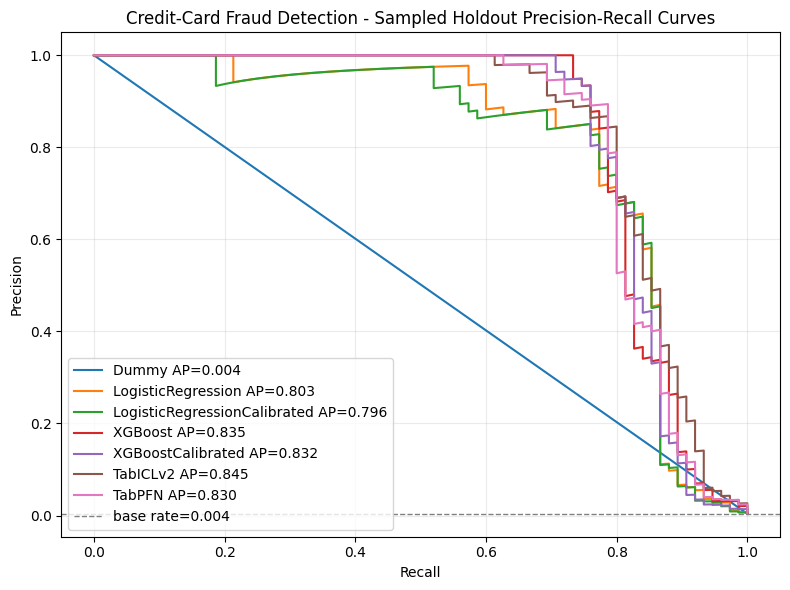

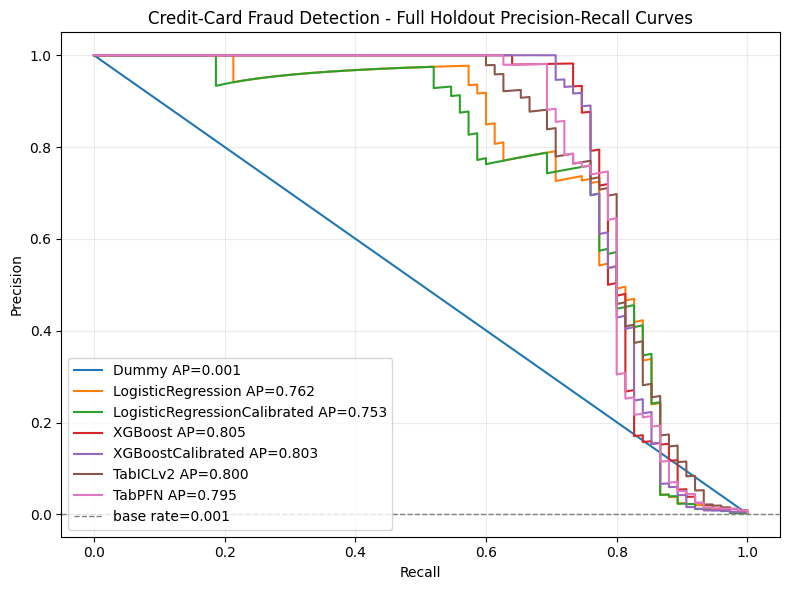

In [10]:
_ = plot_precision_recall_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="sampled",
    title="Credit-Card Fraud Detection - Sampled Holdout Precision-Recall Curves",
    output_path="fraud_precision_recall_curves_sampled.png",
)

_ = plot_precision_recall_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="full",
    title="Credit-Card Fraud Detection - Full Holdout Precision-Recall Curves",
    output_path="fraud_precision_recall_curves_full.png",
)


### What the precision-recall curves show

The precision-recall curves show that XGBoost, TabICLv2, and TabPFN are operating in a similar quality range. The full-holdout curve is especially important because it confirms that the TFM ranking behavior remains competitive at the original fraud base rate, not only on the sampled comparison slice.

The dashed baseline is near zero because fraud is rare. This is why Average Precision and alert-budget metrics are more informative than plain accuracy for this workflow.


## 8. Runtime vs Average Precision

These plots make the practical tradeoff visible: model quality versus fit-plus-predict time. The dummy baseline is excluded so the real model cluster remains readable.

The sampled-holdout view is a fast comparison slice. The full-holdout view is more important for deployment interpretation because it includes the original fraud base rate and now includes TabICL and TabPFN inference as well.


,Model,Family,Holdout,Rows,Average Precision,Brier Score,Total Seconds
0,XGBoost,classical,full,56962,0.8052,0.0004,12.4203
1,XGBoostCalibrated,classical_calibrated,full,56962,0.8033,0.0004,12.1164
2,TabICLv2,tfm,full,56962,0.7999,0.0018,39.3644
3,TabPFN,tfm,full,56962,0.7953,0.0019,87.6781
4,LogisticRegression,classical,full,56962,0.7625,0.0006,2.7467
5,LogisticRegressionCalibrated,classical_calibrated,full,56962,0.7526,0.0006,2.7183
6,TabICLv2,tfm,sampled,20075,0.8454,0.0022,14.4225
7,XGBoost,classical,sampled,20075,0.8348,0.0010,12.3358
8,XGBoostCalibrated,classical_calibrated,sampled,20075,0.8321,0.0011,12.0986
9,TabPFN,tfm,sampled,20075,0.8305,0.0025,31.9096


Saved fraud_runtime_vs_average_precision_sampled.png
Saved fraud_runtime_vs_average_precision_full.png


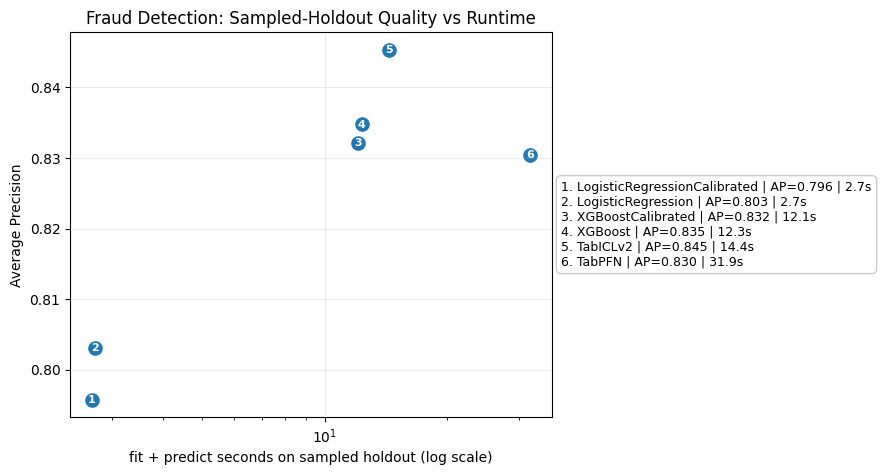

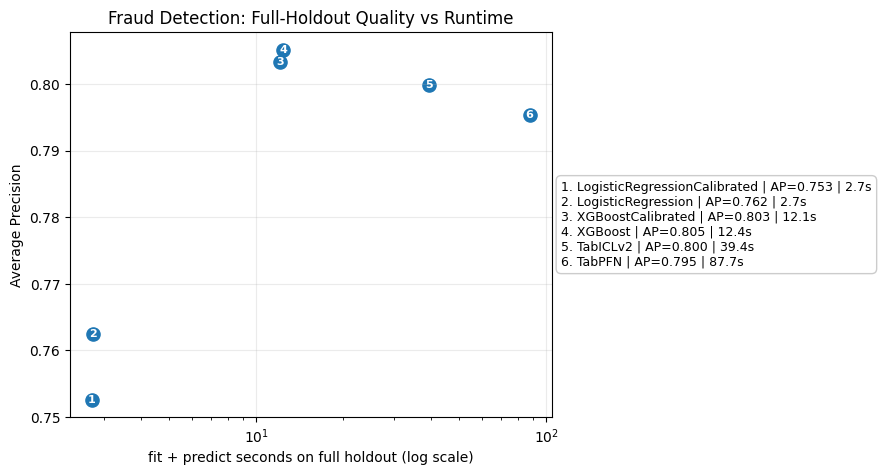

In [11]:
runtime_ap_summary = (
    fraud_summary.loc[
        (fraud_summary["Model"] != "Dummy")
        & fraud_summary["Average Precision"].notna()
        & fraud_summary["Total Seconds"].notna(),
        ["Model", "Family", "Holdout", "Rows", "Average Precision", "Brier Score", "Total Seconds"],
    ]
    .sort_values(["Holdout", "Average Precision"], ascending=[True, False])
    .reset_index(drop=True)
)

display(runtime_ap_summary.round(4))


def plot_runtime_vs_ap(summary, holdout_name, output_path):
    plot_df = summary[summary["Holdout"] == holdout_name].copy()
    plot_df = plot_df.sort_values("Total Seconds").reset_index(drop=True)

    if len(plot_df) == 0:
        print(f"No successful {holdout_name}-holdout model results to plot.")
        return None

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(plot_df["Total Seconds"], plot_df["Average Precision"], s=90)

    for idx, row in plot_df.iterrows():
        ax.annotate(
            str(idx + 1),
            (row["Total Seconds"], row["Average Precision"]),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=8,
        )

    legend_text = "\n".join(
        f"{idx + 1}. {row['Model']} | AP={row['Average Precision']:.3f} | {row['Total Seconds']:.1f}s"
        for idx, row in plot_df.iterrows()
    )
    ax.text(
        1.02,
        0.5,
        legend_text,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "0.8"},
    )

    ax.set_xscale("log")
    ax.set_xlabel(f"fit + predict seconds on {holdout_name} holdout (log scale)")
    ax.set_ylabel("Average Precision")
    ax.set_title(f"Fraud Detection: {holdout_name.title()}-Holdout Quality vs Runtime")
    ax.grid(alpha=0.25)
    fig.subplots_adjust(right=0.66)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig


_ = plot_runtime_vs_ap(
    runtime_ap_summary,
    holdout_name="sampled",
    output_path="fraud_runtime_vs_average_precision_sampled.png",
)

_ = plot_runtime_vs_ap(
    runtime_ap_summary,
    holdout_name="full",
    output_path="fraud_runtime_vs_average_precision_full.png",
)


### What the runtime comparison means

The sampled-holdout runtime view is useful for fast experimentation. The full-holdout runtime view is more useful for deployment planning because it includes inference over the real final holdout.

Use this plot together with the main metric table rather than reading it as a leaderboard. If XGBoost, TabICL, and TabPFN are close by full-holdout Average Precision, the practical question becomes whether any TFM advantage justifies extra runtime, setup friction, authentication, licensing review, or GPU dependence. Conversely, a TFM may still be valuable if it reduces tuning burden, performs better in few-shot settings, or gives stronger review-queue behavior at a chosen alert budget.


## 9. Alert-Budget and Operating-Point View

Fraud teams often cannot investigate every transaction. This section converts model scores into operating decisions: top-percentage alert budgets, fixed alert counts, and the number of alerts needed to reach target recall. This is more deployment-like than ranking models only by Average Precision.


In [12]:
def alert_budget_table(y_true, y_proba, alert_rates=(0.005, 0.01, 0.02, 0.05)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for rate in alert_rates:
        k = max(1, int(np.ceil(rate * len(y_true))))
        selected = order[:k]
        positives_found = int(y_true[selected].sum())
        rows.append(
            {
                "alert_type": "top_rate",
                "alert_value": rate,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def fixed_alert_count_table(y_true, y_proba, alert_counts=(100, 250, 500, 1000)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for k in alert_counts:
        k = min(k, len(y_true))
        selected = order[:k]
        positives_found = int(y_true[selected].sum())
        rows.append(
            {
                "alert_type": "top_count",
                "alert_value": k,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def target_recall_table(y_true, y_proba, target_recalls=(0.80, 0.90)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    sorted_true = y_true[order]
    cumulative_frauds = np.cumsum(sorted_true)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for target_recall in target_recalls:
        required_frauds = target_recall * total_positives
        k = int(np.searchsorted(cumulative_frauds, required_frauds, side="left") + 1)
        k = min(k, len(y_true))
        threshold = y_proba[order[k - 1]]
        positives_found = int(cumulative_frauds[k - 1])
        rows.append(
            {
                "target_recall": target_recall,
                "threshold": threshold,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def all_operating_tables(predictions, y_by_holdout):
    budget_rows = []
    recall_rows = []

    for (model_name, holdout_name), y_proba in predictions.items():
        y_true = y_by_holdout[holdout_name]

        budget_table = pd.concat(
            [
                alert_budget_table(y_true, y_proba),
                fixed_alert_count_table(y_true, y_proba),
            ],
            ignore_index=True,
        )
        budget_table.insert(0, "Holdout", holdout_name)
        budget_table.insert(0, "Model", model_name)
        budget_rows.append(budget_table)

        recall_table = target_recall_table(y_true, y_proba)
        recall_table.insert(0, "Holdout", holdout_name)
        recall_table.insert(0, "Model", model_name)
        recall_rows.append(recall_table)

    return pd.concat(budget_rows, ignore_index=True), pd.concat(recall_rows, ignore_index=True)


if not fraud_predictions:
    print("No successful model predictions available for operating-point analysis.")
else:
    alert_summary, recall_summary = all_operating_tables(fraud_predictions, y_by_holdout)
    display(alert_summary.round(4))
    display(recall_summary.round(4))


,Model,Holdout,alert_type,alert_value,alerts,frauds_found,precision,recall
0,Dummy,sampled,top_rate,0.005,101,0,0.0000,0.0000
1,Dummy,sampled,top_rate,0.010,201,0,0.0000,0.0000
2,Dummy,sampled,top_rate,0.020,402,0,0.0000,0.0000
3,Dummy,sampled,top_rate,0.050,1004,4,0.0040,0.0533
4,Dummy,sampled,top_count,100.000,100,0,0.0000,0.0000
...,...,...,...,...,...,...,...,...
107,TabPFN,full,top_rate,0.050,2849,70,0.0246,0.9333
108,TabPFN,full,top_count,100.000,100,60,0.6000,0.8000
109,TabPFN,full,top_count,250.000,250,62,0.2480,0.8267
110,TabPFN,full,top_count,500.000,500,65,0.1300,0.8667


,Model,Holdout,target_recall,threshold,alerts,frauds_found,precision,recall
0,Dummy,sampled,0.8,0.0018,12444,60,0.0048,0.8000
1,Dummy,sampled,0.9,0.0018,16926,68,0.0040,0.9067
2,Dummy,full,0.8,0.0018,35261,60,0.0017,0.8000
3,Dummy,full,0.9,0.0018,48140,68,0.0014,0.9067
4,LogisticRegression,sampled,0.8,0.0323,84,60,0.7143,0.8000
5,LogisticRegression,sampled,0.9,0.0035,1012,68,0.0672,0.9067
6,LogisticRegression,full,0.8,0.0323,111,60,0.5405,0.8000
7,LogisticRegression,full,0.9,0.0035,2776,68,0.0245,0.9067
8,LogisticRegressionCalibrated,sampled,0.8,0.0335,81,60,0.7407,0.8000
9,LogisticRegressionCalibrated,sampled,0.9,0.0006,1064,68,0.0639,0.9067


### What the alert-budget tables mean

This is the most deployment-like view in the notebook. Fraud teams usually operate review queues, not abstract model scores. The target-recall table shows how many transactions would need to be reviewed to recover a chosen fraction of fraud cases.

When headline Average Precision values are close, compare the alert counts needed at the same target recall and the frauds found at the same alert budget. A model with similar AP can still be operationally better if it finds the same fraud volume with fewer review slots.

The thresholds in this table are score cutoffs, not guaranteed calibrated fraud probabilities. They should be treated as operating-point choices for ranking and queue construction unless the probability calibration has been validated separately.


## 10. Calibration Diagnostics

Fraud scores are often used for ranking, but operational thresholds depend on probability behavior. Brier score is reported in the main metric table. The calibrated classical variants use a separate full-prevalence calibration window rather than the validation window used for model selection.

The plots below are zoomed into the rare-event probability range. A full 0-1 calibration plot is not very useful here because almost every meaningful point sits near zero. With only a few dozen fraud examples in the validation and calibration windows, these curves are diagnostics for model behavior, not a production calibration certificate.

A useful finding in this run is that TabICL and TabPFN are strong rankers, but their raw probability scale is less trustworthy than their Average Precision alone suggests. On the full holdout, TabICL and TabPFN are close to XGBoost by AP, while the calibrated classical variants have much better Brier/log-loss behavior. For fraud operations, that means TFM scores may be useful for ranking and alert queues, but raw TFM probabilities should be calibrated or otherwise validated before threshold-governed deployment.


Saved fraud_calibration_curves_sampled.png
Saved fraud_calibration_curves_full.png


,Model,Family,Holdout,Average Precision,Brier Score,Log Loss
0,XGBoost,classical,full,0.8052,0.0004,0.0026
1,XGBoostCalibrated,classical_calibrated,full,0.8033,0.0004,0.0032
2,TabICLv2,tfm,full,0.7999,0.0018,0.0132
3,TabPFN,tfm,full,0.7953,0.0019,0.0116
4,LogisticRegression,classical,full,0.7625,0.0006,0.0039
5,LogisticRegressionCalibrated,classical_calibrated,full,0.7526,0.0006,0.0030
6,Dummy,baseline,full,0.0013,0.0013,0.0101
7,TabICLv2,tfm,sampled,0.8454,0.0022,0.0147
8,XGBoost,classical,sampled,0.8348,0.0010,0.0069
9,XGBoostCalibrated,classical_calibrated,sampled,0.8321,0.0011,0.0082


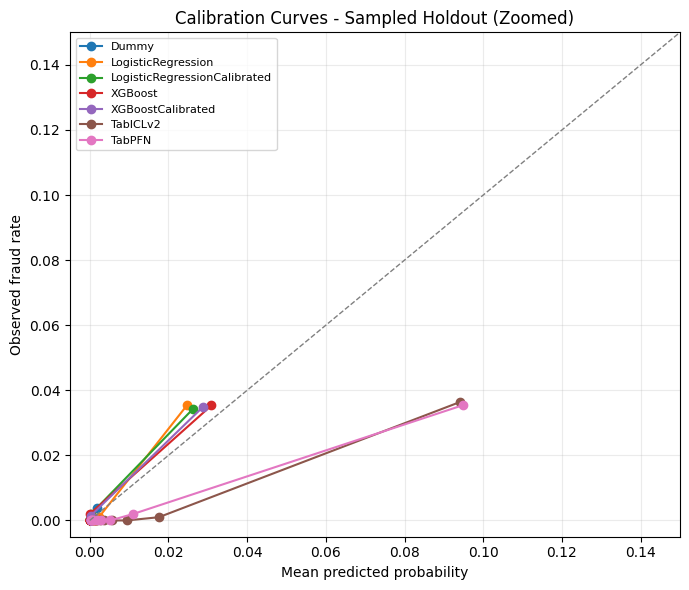

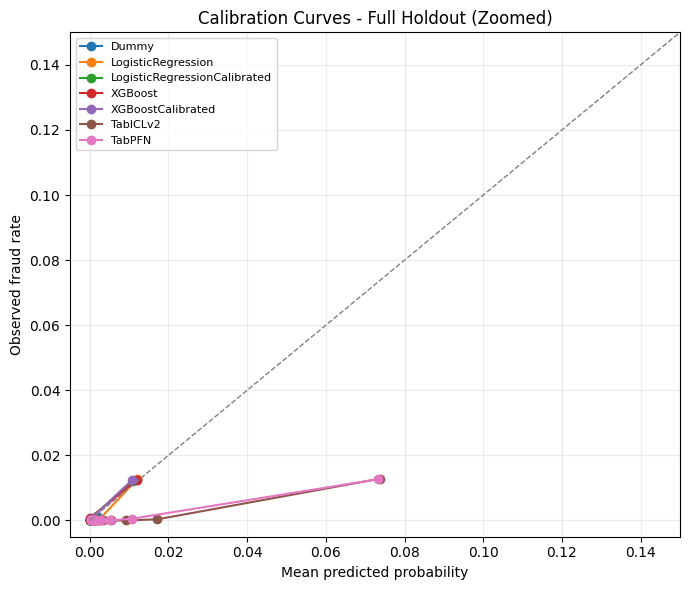

In [13]:
def plot_calibration_curves(predictions, y_by_holdout, holdout_name, output_path=None, max_axis=0.15):
    fig, ax = plt.subplots(figsize=(7, 6))
    plotted = False

    for (model_name, prediction_holdout), y_proba in predictions.items():
        if prediction_holdout != holdout_name:
            continue
        y_true = y_by_holdout[holdout_name]
        prob_true, prob_pred = calibration_curve(
            y_true,
            y_proba,
            n_bins=10,
            strategy="quantile",
        )
        ax.plot(prob_pred, prob_true, marker="o", label=model_name)
        plotted = True

    if not plotted:
        print(f"No successful model predictions to plot for holdout={holdout_name}.")
        return None

    ax.plot([0, max_axis], [0, max_axis], color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-0.005, max_axis)
    ax.set_ylim(-0.005, max_axis)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraud rate")
    ax.set_title(f"Calibration Curves - {holdout_name.title()} Holdout (Zoomed)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
        print(f"Saved {output_path}")

    return fig


_ = plot_calibration_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="sampled",
    output_path="fraud_calibration_curves_sampled.png",
)

_ = plot_calibration_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="full",
    output_path="fraud_calibration_curves_full.png",
)

calibration_quality_view = (
    fraud_summary.loc[
        fraud_summary["Average Precision"].notna(),
        ["Model", "Family", "Holdout", "Average Precision", "Brier Score", "Log Loss"],
    ]
    .sort_values(["Holdout", "Average Precision"], ascending=[True, False])
    .reset_index(drop=True)
)

display(calibration_quality_view.round(4))


### What the calibration results mean

The calibration view separates ranking quality from probability quality. TabICL and TabPFN are competitive rankers in this run, but their raw probability scale is less reliable than their Average Precision alone suggests. The calibrated classical variants have better Brier/log-loss behavior, which is what I would want for threshold policies that treat scores as probabilities.

For this notebook, the safe conclusion is: TFM scores look useful for ranking and alert queues; raw TFM probabilities should not be treated as calibrated risk estimates without additional calibration or validation.


## 11. Leakage and Reuse Checklist

This dataset is anonymized, so some production checks cannot be fully resolved. The point of this section is to make the reusable workflow explicit: before trusting any fraud result, check chronological ordering, feature availability, duplicates, target leakage, and entity-level leakage.

Rows can share the same `Time` value, so the split check below is about chronological ordering by row position after sorting, not a claim that boundary timestamp values are strictly separated. In this sensitivity run, `Time` is included as a model feature, so any gain from it should be reviewed as possible period-specific behavior rather than assumed production signal.

The duplicate-row check is expanded because exact duplicates and duplicate model-feature rows can change alert-budget interpretation. The model-feature duplicate check uses the current feature set. Because this sensitivity run includes `Time`, duplicate model-feature rows are expected to match exact duplicates more closely than in the default `USE_TIME_AS_FEATURE = False` run. In a real fraud project, repeated-looking transactions may be legitimate recurring payments, retries, or duplicated records. This public dataset does not expose enough raw identifiers to fully adjudicate them, so the notebook reports the issue rather than silently ignoring it.


In [15]:
window_labels = pd.Series(index=df.index, dtype="object")
window_labels.iloc[:train_end_idx] = "train"
window_labels.iloc[train_end_idx:validation_end_idx] = "validation"
window_labels.iloc[validation_end_idx:calibration_end_idx] = "calibration"
window_labels.iloc[calibration_end_idx:] = "test"


def summarize_duplicate_groups(group_hashes, labels, class_values):
    duplicate_frame = pd.DataFrame(
        {
            "duplicate_group": group_hashes,
            "window": labels,
            "Class": class_values.astype(int),
        }
    )
    group_sizes = duplicate_frame.groupby("duplicate_group").size()
    repeated_group_ids = group_sizes[group_sizes > 1].index
    duplicate_detail = duplicate_frame[duplicate_frame["duplicate_group"].isin(repeated_group_ids)].copy()

    if len(duplicate_detail) == 0:
        duplicate_group_summary = pd.DataFrame(
            columns=["duplicate_group", "rows", "windows", "fraud_rows"]
        )
        return duplicate_detail, duplicate_group_summary, 0

    duplicate_group_summary = (
        duplicate_detail.groupby("duplicate_group")
        .agg(rows=("Class", "size"), windows=("window", "nunique"), fraud_rows=("Class", "sum"))
        .reset_index()
    )
    cross_window_groups = int((duplicate_group_summary["windows"] > 1).sum())
    return duplicate_detail, duplicate_group_summary, cross_window_groups


exact_duplicate_group = pd.util.hash_pandas_object(df, index=False)
feature_duplicate_group = pd.util.hash_pandas_object(df[feature_columns], index=False)

exact_duplicate_detail, exact_duplicate_group_summary, exact_cross_window_groups = summarize_duplicate_groups(
    exact_duplicate_group,
    window_labels,
    df[target_column],
)
feature_duplicate_detail, feature_duplicate_group_summary, feature_cross_window_groups = summarize_duplicate_groups(
    feature_duplicate_group,
    window_labels,
    df[target_column],
)

exact_duplicate_rows = int(len(exact_duplicate_detail))
feature_duplicate_rows = int(len(feature_duplicate_detail))

feature_cross_window_fraud_rows = 0
if len(feature_duplicate_group_summary) > 0:
    feature_cross_window_ids = feature_duplicate_group_summary.loc[
        feature_duplicate_group_summary["windows"] > 1,
        "duplicate_group",
    ]
    feature_cross_window_fraud_rows = int(
        feature_duplicate_detail.loc[
            feature_duplicate_detail["duplicate_group"].isin(feature_cross_window_ids),
            "Class",
        ].sum()
    )

duplicate_diagnostics = pd.DataFrame(
    [
        {"metric": "exact_duplicate_rows_including_time_and_target", "value": exact_duplicate_rows},
        {"metric": "exact_duplicate_groups_including_time_and_target", "value": len(exact_duplicate_group_summary)},
        {"metric": "exact_duplicate_groups_crossing_time_windows", "value": exact_cross_window_groups},
        {"metric": "model_feature_duplicate_rows", "value": feature_duplicate_rows},
        {"metric": "model_feature_duplicate_groups", "value": len(feature_duplicate_group_summary)},
        {"metric": "model_feature_duplicate_groups_crossing_time_windows", "value": feature_cross_window_groups},
        {"metric": "fraud_rows_inside_cross_window_model_feature_duplicate_groups", "value": feature_cross_window_fraud_rows},
    ]
)
display(duplicate_diagnostics)

if exact_duplicate_rows > 0:
    print("Exact duplicate rows by time window and class:")
    exact_duplicate_by_window_and_class = (
        exact_duplicate_detail.groupby(["window", "Class"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={0: "non_fraud_duplicate_rows", 1: "fraud_duplicate_rows"})
        .reset_index()
    )
    display(exact_duplicate_by_window_and_class)
else:
    print("No exact duplicate rows found when Time and Class are included.")

if feature_duplicate_rows > 0:
    print("Largest duplicate groups based on model features only:")
    display(
        feature_duplicate_group_summary.sort_values(["windows", "rows"], ascending=[False, False])
        .head(10)
        .drop(columns=["duplicate_group"])
    )

    if feature_cross_window_groups > 0:
        print("Model-feature duplicate groups crossing time windows need review:")
        display(
            feature_duplicate_group_summary.loc[feature_duplicate_group_summary["windows"] > 1]
            .sort_values(["windows", "rows"], ascending=[False, False])
            .head(10)
            .drop(columns=["duplicate_group"])
        )
    else:
        print("No duplicate model-feature groups cross time windows.")
else:
    print("No duplicate model-feature rows found.")

chronological_split_ordered = (
    train_period["Time"].max() <= validation_period["Time"].min()
    and validation_period["Time"].max() <= calibration_period["Time"].min()
    and calibration_period["Time"].max() <= test_period["Time"].min()
)

duplicate_status = "review" if exact_duplicate_rows > 0 or feature_cross_window_groups > 0 else "pass"

leakage_checks = pd.DataFrame(
    [
        {
            "Check": "Target excluded from features",
            "Status": "pass" if target_column not in feature_columns else "fail",
            "Evidence": f"target_column={target_column}; feature_count={len(feature_columns)}",
        },
        {
            "Check": "Time column preserved for temporal split",
            "Status": "pass" if "Time" in df.columns else "fail",
            "Evidence": f"Time range {df['Time'].min():.0f} to {df['Time'].max():.0f}" if "Time" in df.columns else "Time missing",
        },
        {
            "Check": "Time used as model feature",
            "Status": "review" if "Time" in feature_columns else "not_used_as_feature",
            "Evidence": f"USE_TIME_AS_FEATURE={USE_TIME_AS_FEATURE}; Time in feature_columns={'Time' in feature_columns}",
        },
        {
            "Check": "Chronological split order",
            "Status": "pass" if chronological_split_ordered else "review",
            "Evidence": f"sorted by Time before splitting; equal boundary timestamps can occur; train max={train_period['Time'].max():.0f}, validation min={validation_period['Time'].min():.0f}, validation max={validation_period['Time'].max():.0f}, calibration min={calibration_period['Time'].min():.0f}, calibration max={calibration_period['Time'].max():.0f}, test min={test_period['Time'].min():.0f}",
        },
        {
            "Check": "Duplicate rows and duplicate model-feature rows",
            "Status": duplicate_status,
            "Evidence": f"exact_duplicate_rows={exact_duplicate_rows:,}; exact_cross_window_groups={exact_cross_window_groups:,}; model_feature_duplicate_rows={feature_duplicate_rows:,}; model_feature_cross_window_groups={feature_cross_window_groups:,}",
        },
        {
            "Check": "Future aggregate features",
            "Status": "unknown",
            "Evidence": "V1-V28 are anonymized PCA-style features; raw feature lineage is not available in this public dataset.",
        },
        {
            "Check": "Entity-level leakage / customer grouping",
            "Status": "unknown",
            "Evidence": "No customer/card/account identifier is available, so group-based splitting cannot be tested here.",
        },
        {
            "Check": "Label delay / chargeback availability",
            "Status": "unknown",
            "Evidence": "The public dataset does not expose when the fraud label became known.",
        },
    ]
)

display(leakage_checks)


,metric,value
0,exact_duplicate_rows_including_time_and_target,1854
1,exact_duplicate_groups_including_time_and_target,773
2,exact_duplicate_groups_crossing_time_windows,0
3,model_feature_duplicate_rows,1854
4,model_feature_duplicate_groups,773
5,model_feature_duplicate_groups_crossing_time_w...,0
6,fraud_rows_inside_cross_window_model_feature_d...,0


Exact duplicate rows by time window and class:


Class,window,non_fraud_duplicate_rows,fraud_duplicate_rows
0,calibration,206,0
1,test,390,2
2,train,1086,30
3,validation,140,0


Largest duplicate groups based on model features only:


,rows,windows,fraud_rows
210,18,1,0
695,18,1,0
190,9,1,0
417,9,1,0
264,6,1,6
175,5,1,0
215,5,1,0
321,5,1,0
477,5,1,0
502,5,1,0


No duplicate model-feature groups cross time windows.


,Check,Status,Evidence
0,Target excluded from features,pass,target_column=Class; feature_count=30
1,Time column preserved for temporal split,pass,Time range 0 to 172792
2,Time used as model feature,review,USE_TIME_AS_FEATURE=True; Time in feature_colu...
3,Chronological split order,pass,sorted by Time before splitting; equal boundar...
4,Duplicate rows and duplicate model-feature rows,review,"exact_duplicate_rows=1,854; exact_cross_window..."
5,Future aggregate features,unknown,V1-V28 are anonymized PCA-style features; raw ...
6,Entity-level leakage / customer grouping,unknown,No customer/card/account identifier is availab...
7,Label delay / chargeback availability,unknown,The public dataset does not expose when the fr...


### What the leakage checklist means

The main structural checks are the ones professionals should expect: the target is excluded from features, `Time` is used for chronological splitting rather than modeling, and the split is chronologically ordered even though equal boundary timestamp values can occur.

The duplicate diagnostics report two levels: exact duplicate rows including `Time` and `Class`, and duplicate model-feature rows using only the features the models actually see. Exact duplicates can affect data-quality interpretation. Model-feature duplicates crossing time windows are the stricter leakage signal because they could make train and holdout examples indistinguishable to the model.

Important production questions remain unresolved because the public dataset is anonymized. In a real fraud workflow, I would still need customer/account identifiers for group-aware splitting, raw feature lineage to check future aggregates, and label timing to model chargeback or investigation delay.


## 12. Time Feature Policy

This sensitivity run sets `USE_TIME_AS_FEATURE = True`. The goal is not to claim that `Time` should automatically be used in production, but to test whether models benefit from position-in-dataset information on this public fraud dataset.

Compare this notebook against the default `USE_TIME_AS_FEATURE = False` run. Treat any gain from `Time` as a signal to investigate whether an equivalent timestamp-derived feature would be available, stable, and acceptable in the intended production setting.
